# IHDP Agent: Pitch Step Tracking on the Nonlinear B-737

This notebook trains an **Incremental Heuristic Dynamic Programming (IHDP)** agent to control the pitch angle $\theta$ of the **pure-numpy nonlinear Boeing 737 6-DoF model** through the registered **Gymnasium** environment `NonlinearB737-v0`.

The task is intentionally simple and transparent for control-system work:

* Cruise trim: FL200, $V = 650$ ft/s, B737-800 configuration.
* Initial hold: the reference is equal to the trim pitch for 15 seconds.
* Command: a $+1^\circ$ pitch step at $t = 15$ s.
* Control architecture: IHDP-only residual elevator control around the trim point.

The trim elevator and trim throttle are fixed operating-point terms, not a PD controller:

$$
\delta_e(t) = \delta_{e,\mathrm{trim}} + \delta_{e,\mathrm{IHDP}}(t),
\qquad
\delta_a = 0,\quad \delta_r = 0,\quad \delta_T = \delta_{T,\mathrm{trim}}.
$$

The agent observes and tracks `[d_theta, q]`, where `d_theta = theta - theta_trim` and `q` is pitch rate. Including `q -> 0` gives the IHDP critic a damping state without adding an external PD loop.


**Paper-equation update:** the SISO actor gradient now includes the physical output scale. The actor learning rate and its floor are expressed in these units. This experiment includes the optional integral correction.

**Primary quality criterion:** the Composite performance index from `ControlBenchmark` on the complete post-step interval (15–59.98 s), using radians and dt=0.02 s. Lower is better. The 15-second transient window is reported separately. The actor rate factor 1.01 is selected by CPI; compare rise/settling time and command-relative error as well, since they can move in opposite directions.

## 1. Imports


In [1]:
import torch
import numpy as np
torch.set_num_threads(1)
np.random.seed(0)
torch.manual_seed(0)
import math
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

import tensoraerospace  # noqa: F401  -- registers Gymnasium envs
from tensoraerospace.aerospacemodel.b737.nonlinear import (
    B737Configuration,
    trim,
)
from tensoraerospace.agent.ihdp.model import IHDPAgent
from tensoraerospace.benchmark.bench import ControlBenchmark
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

warnings.filterwarnings("ignore")


## 2. Compute the B-737 cruise trim

The nonlinear B-737 trimmer solves $\dot u = \dot w = \dot q = 0$ for level cruise and returns:

* trim angle of attack $\alpha_0$;
* trim elevator $\delta_{e,0}$;
* trim throttle $\delta_{T,0}$;
* a 12-state vector compatible with the Gymnasium environment.

For level cruise, $\theta_0 = \alpha_0$.


In [2]:
ALTITUDE_FT = 20_000.0
AIRSPEED_FT_S = 650.0
CONFIG = B737Configuration.B737_800

trim_result = trim(
    altitude_ft=ALTITUDE_FT,
    V_ft_s=AIRSPEED_FT_S,
    config=CONFIG,
)
assert trim_result.converged, f"trim failed: residual={trim_result.residual:.2e}"

alpha_trim_rad = float(trim_result.alpha_rad)
theta_trim_rad = alpha_trim_rad
delta_e_trim_deg = math.degrees(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)

print(f"trim @ FL{ALTITUDE_FT/100:.0f}, V={AIRSPEED_FT_S:.0f} ft/s, {CONFIG.value}:")
print(f"  alpha_trim   = {math.degrees(alpha_trim_rad):+.3f} deg")
print(f"  theta_trim   = {math.degrees(theta_trim_rad):+.3f} deg")
print(f"  delta_e_trim = {delta_e_trim_deg:+.3f} deg")
print(f"  throttle     = {throttle_trim:.4f}")
print(f"  residual     = {trim_result.residual:.2e}")


trim @ FL200, V=650 ft/s, 737-800:
  alpha_trim   = +2.012 deg
  theta_trim   = +2.012 deg
  delta_e_trim = -1.175 deg
  throttle     = 0.4769
  residual     = 8.25e-11


## 3. Time grid and pitch reference

The episode lasts 60 seconds with `dt = 0.02` s. The first 15 seconds are an exact trim hold. The reference then steps by $+1^\circ$ in pitch deviation.

The IHDP tracking signal is in radians and in deviation-from-trim coordinates:

$$
r(t) = [\Delta \theta_\mathrm{ref}(t),\, 0]^\top.
$$


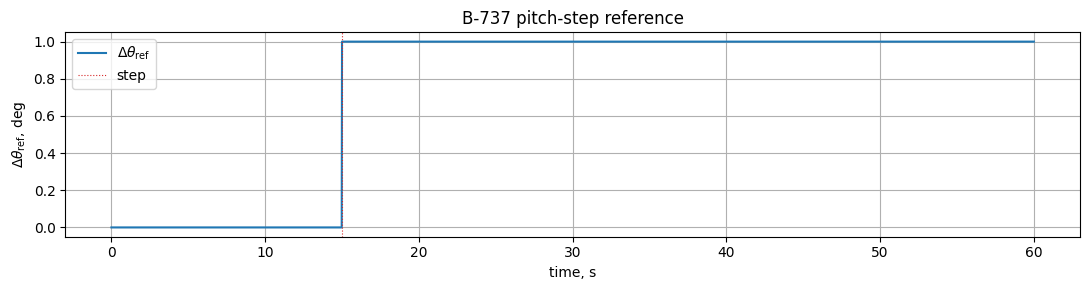

In [3]:
dt = 0.02
tp = generate_time_period(tn=60.0, dt=dt)
tps = convert_tp_to_sec_tp(tp, dt=dt)
number_time_steps = len(tp)

step_amplitude_deg = 1.0
step_time_sec = 15.0
step_index = int(step_time_sec / dt)

ref_dev_deg = np.zeros(number_time_steps)
ref_dev_deg[step_index:] = step_amplitude_deg

ref_dev_rad = np.deg2rad(ref_dev_deg)
ref_q_rad_s = np.zeros(number_time_steps)
reference_signal = np.vstack([ref_dev_rad, ref_q_rad_s])

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(tps, ref_dev_deg, label=r"$\Delta\theta_{\mathrm{ref}}$")
ax.axvline(step_time_sec, color="tab:red", linestyle=":", linewidth=0.8, label="step")
ax.set_xlabel("time, s")
ax.set_ylabel(r"$\Delta\theta_{\mathrm{ref}}$, deg")
ax.set_title("B-737 pitch-step reference")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Build the nonlinear B-737 Gymnasium environment

The plant is created through `gym.make("NonlinearB737-v0", ...)`. The action space is `"virtual"`, so the environment receives physical commands:

$$
[\delta_e,\ \delta_a,\ \delta_r,\ \delta_T],
$$

with angular channels in radians and throttle in `[0, 1]`.


In [4]:
env = gym.make(
    "NonlinearB737-v0",
    trim_at=(ALTITUDE_FT, AIRSPEED_FT_S),
    number_time_steps=number_time_steps,
    dt=dt,
    integrator="rk4",
    action_space="virtual",
    config=CONFIG,
)

obs, _ = env.reset(seed=47)
print("gym env wrapper: ", type(env).__name__)
print("unwrapped env:   ", type(env.unwrapped).__name__)
print("observation_space:", env.observation_space)
print("action_space:     ", env.action_space)
print("initial obs (12-D state):")
print("  u, v, w  (ft/s) :", obs[:3])
print("  p, q, r  (rad/s):", obs[3:6])
print("  phi, theta, psi :", obs[6:9])
print("  x_e, y_e, z_e   :", obs[9:12])


gym env wrapper:  OrderEnforcing
unwrapped env:    NonlinearB737Env
observation_space: Box(-inf, inf, (12,), float64)
action_space:      Box([-0.30019663 -0.35081118 -0.35081118  0.        ], [0.30019663 0.35081118 0.35081118 1.        ], (4,), float64)
initial obs (12-D state):
  u, v, w  (ft/s) : [649.59941988   0.          22.81652245]
  p, q, r  (rad/s): [0. 0. 0.]
  phi, theta, psi : [0.         0.03510955 0.        ]
  x_e, y_e, z_e   : [     0.      0. -20000.]


## 5. IHDP agent configuration

The IHDP agent sees only the longitudinal tracking state:

* `d_theta` — pitch deviation from trim, rad;
* `q` — pitch rate, rad/s.

It outputs one control channel:

* `d_elev` — residual elevator command, deg.

The residual is limited to $\pm 4^\circ$. A short 5-second persistent-excitation interval is used before the step so the incremental model can identify the local elevator-to-pitch sensitivity around trim.

`use_integral_correction` is the built-in IHDP actor correction available in `IHDPAgent`; it removes the tiny steady-state offset left by the online neural actor. There is still no external PD controller.


In [5]:
random_seed = 47
np.random.seed(random_seed)
torch.manual_seed(random_seed)

state_space = ["d_theta", "q"]
tracking_states = ["d_theta", "q"]
control_space = ["d_elev"]
indices_tracking_states = [0, 1]
pe_duration_sec = 5.0

actor_settings = {
    "start_training": 5,
    "layers": (25, 1),
    "activations": ("tanh", "tanh"),
    "learning_rate": 1.5 / 4.0 * 1.01,
    "learning_rate_min": 0.001 / 4.0 * 1.01,
    "learning_rate_exponent_limit": 10,
    "type_PE": "combined",
    "amplitude_3211": 0.4,
    "pulse_length_3211": pe_duration_sec / dt,
    "maximum_input": 4,
    "maximum_q_rate": 20,
    "WB_limits": 30,
    "NN_initial": random_seed,
    "cascade_actor": False,
    "learning_rate_cascaded": 1.2,
    "use_integral_correction": True,
    "integral_gain": 50.0,
    "integral_clamp_deg": 1.0,
    "integral_warmup_steps": step_index + int(0.2 / dt),
}

critic_settings = {
    "Q_weights": [30000, 40],
    "start_training": -1,
    "gamma": 0.99,
    "learning_rate": 10,
    "learning_rate_exponent_limit": 10,
    "layers": (25, 1),
    "activations": ("tanh", "linear"),
    "WB_limits": 30,
    "NN_initial": random_seed,
    "indices_tracking_states": indices_tracking_states,
}

incremental_settings = {
    "number_time_steps": number_time_steps,
    "dt": dt,
    "input_magnitude_limits": actor_settings["maximum_input"],
    "input_rate_limits": 20,
}

agent = IHDPAgent(
    actor_settings,
    critic_settings,
    incremental_settings,
    tracking_states,
    state_space,
    control_space,
    number_time_steps,
    indices_tracking_states,
)


## 6. Online IHDP rollout through Gymnasium

At each sample:

1. Extract `[d_theta, q]` from the 12-state observation.
2. Ask IHDP for the next elevator residual.
3. Compose the physical Gymnasium action.
4. Call `env.step(action)`.

Only the B-737 trim elevator and trim throttle are added outside the agent.


In [6]:
def deviation_state(obs: np.ndarray) -> np.ndarray:
    # Extract `[d_theta, q]` from the 12-D B-737 state.
    return np.array([
        [float(obs[7]) - theta_trim_rad],
        [float(obs[4])],
    ], dtype=np.float64)


obs, _ = env.reset(seed=random_seed)
xt = deviation_state(obs)

theta_log = np.zeros(number_time_steps)
q_log = np.zeros(number_time_steps)
u_speed_log = np.zeros(number_time_steps)
altitude_log = np.zeros(number_time_steps)
delta_e_total_log = np.zeros(number_time_steps)
delta_e_residual_log = np.zeros(number_time_steps)
throttle_log = np.zeros(number_time_steps)

theta_log[0] = obs[7]
q_log[0] = obs[4]
u_speed_log[0] = float(np.linalg.norm(obs[:3]))
altitude_log[0] = -obs[11]
delta_e_total_log[0] = delta_e_trim_deg
delta_e_residual_log[0] = 0.0
throttle_log[0] = throttle_trim
n_filled = 1

elevator_low_rad = float(env.action_space.low[0])
elevator_high_rad = float(env.action_space.high[0])

for step in tqdm(range(number_time_steps - 3)):
    ut = agent.predict(xt, reference_signal, step)
    delta_e_residual_deg = float(np.asarray(ut).flatten()[0])

    delta_e_total_rad = np.clip(
        math.radians(delta_e_trim_deg + delta_e_residual_deg),
        elevator_low_rad,
        elevator_high_rad,
    )
    delta_e_total_deg = math.degrees(delta_e_total_rad)

    action = np.array([
        delta_e_total_rad,
        0.0,
        0.0,
        throttle_trim,
    ], dtype=np.float64)

    obs, _reward, terminated, truncated, _info = env.step(action)
    xt = deviation_state(obs)

    log_index = step + 1
    theta_log[log_index] = obs[7]
    q_log[log_index] = obs[4]
    u_speed_log[log_index] = float(np.linalg.norm(obs[:3]))
    altitude_log[log_index] = -obs[11]
    delta_e_total_log[log_index] = delta_e_total_deg
    delta_e_residual_log[log_index] = delta_e_residual_deg
    throttle_log[log_index] = throttle_trim
    n_filled = log_index + 1

    if terminated or truncated:
        break


## 7. Tracking plots


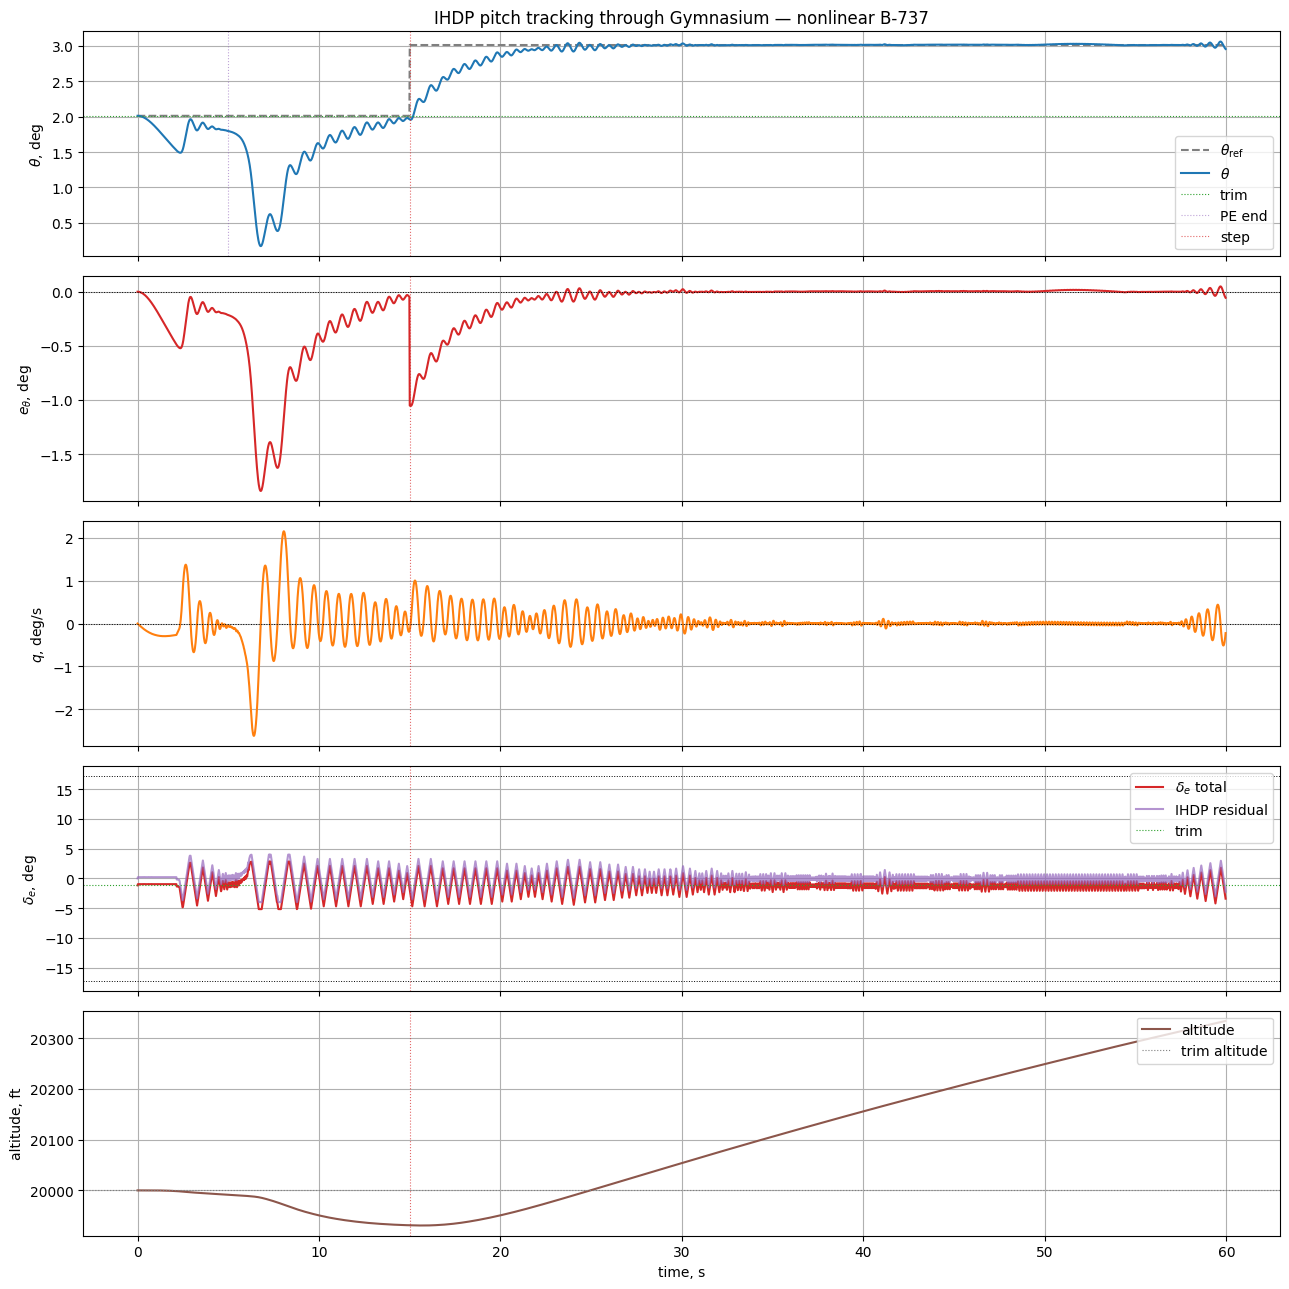

In [7]:
theta_deg = np.rad2deg(theta_log[:n_filled])
theta_dev_deg = theta_deg - math.degrees(theta_trim_rad)
q_deg_s = np.rad2deg(q_log[:n_filled])
ref_full_deg = math.degrees(theta_trim_rad) + ref_dev_deg[:n_filled]
t_axis = tps[:n_filled]

fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True)

axes[0].plot(t_axis, ref_full_deg, "--", color="tab:gray", label=r"$\theta_{\mathrm{ref}}$")
axes[0].plot(t_axis, theta_deg, color="tab:blue", label=r"$\theta$")
axes[0].axhline(math.degrees(theta_trim_rad), color="tab:green",
                linestyle=":", linewidth=0.8, label="trim")
axes[0].axvline(pe_duration_sec, color="tab:purple", linestyle=":", linewidth=0.8, alpha=0.6, label="PE end")
axes[0].axvline(step_time_sec, color="tab:red", linestyle=":", linewidth=0.8, alpha=0.7, label="step")
axes[0].set_ylabel(r"$\theta$, deg")
axes[0].set_title("IHDP pitch tracking through Gymnasium — nonlinear B-737")
axes[0].grid(True)
axes[0].legend(loc="lower right")

axes[1].plot(t_axis, theta_dev_deg - ref_dev_deg[:n_filled], color="tab:red")
axes[1].axhline(0.0, color="k", linestyle=":", linewidth=0.7)
axes[1].axvline(step_time_sec, color="tab:red", linestyle=":", linewidth=0.8, alpha=0.7)
axes[1].set_ylabel(r"$e_\theta$, deg")
axes[1].grid(True)

axes[2].plot(t_axis, q_deg_s, color="tab:orange")
axes[2].axhline(0.0, color="k", linestyle=":", linewidth=0.7)
axes[2].axvline(step_time_sec, color="tab:red", linestyle=":", linewidth=0.8, alpha=0.7)
axes[2].set_ylabel(r"$q$, deg/s")
axes[2].grid(True)

axes[3].plot(t_axis, delta_e_total_log[:n_filled], color="tab:red", label=r"$\delta_e$ total")
axes[3].plot(t_axis, delta_e_residual_log[:n_filled], color="tab:purple",
             alpha=0.7, label="IHDP residual")
axes[3].axhline(delta_e_trim_deg, color="tab:green", linestyle=":", linewidth=0.8, label="trim")
axes[3].axhline(math.degrees(elevator_high_rad), color="k", linestyle=":", linewidth=0.7)
axes[3].axhline(math.degrees(elevator_low_rad), color="k", linestyle=":", linewidth=0.7)
axes[3].axvline(step_time_sec, color="tab:red", linestyle=":", linewidth=0.8, alpha=0.7)
axes[3].set_ylabel(r"$\delta_e$, deg")
axes[3].grid(True)
axes[3].legend(loc="upper right")

axes[4].plot(t_axis, altitude_log[:n_filled], color="tab:brown", label="altitude")
axes[4].axhline(ALTITUDE_FT, color="tab:gray", linestyle=":", linewidth=0.8, label="trim altitude")
axes[4].axvline(step_time_sec, color="tab:red", linestyle=":", linewidth=0.8, alpha=0.7)
axes[4].set_xlabel("time, s")
axes[4].set_ylabel("altitude, ft")
axes[4].grid(True)
axes[4].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 8. Step-response metrics: Composite performance index

The primary score uses the **complete post-step interval, 15–59.98 s**, in radians with dt=0.02 s. Lower CPI is better. The first 15 seconds after the step are also reported as a separate window; compare scores only with identical windows and units.

The library CPI combines ISE, ITAE and overshoot relative to the final response. Command-relative settling and overshoot are reported separately. In this run, late oscillations leave the ±5% command band, so the full-window command settling time is undefined despite a lower CPI. “Settled RMSE” below names a fixed diagnostic window beginning 10 seconds after the step; it does not assert that settling occurred.

In [8]:
n_eval = n_filled
theta_rad = theta_log[:n_eval]
theta_dev_rad = theta_rad - theta_trim_rad
theta_dev_deg = np.rad2deg(theta_dev_rad)
q_deg_s = np.rad2deg(q_log[:n_eval])
ref_dev_rad_eval = ref_dev_rad[:n_eval]
ref_dev_deg_eval = ref_dev_deg[:n_eval]
err_deg = theta_dev_deg - ref_dev_deg_eval

pe_end_index = min(int(pe_duration_sec / dt), n_eval)
post_step_start = min(step_index, n_eval - 1)
settled_start = min(n_eval - 1, step_index + int(10.0 / dt))
bench_start = max(0, step_index - int(1.0 / dt))
bench_window_sec = 15.0
bench_end = min(n_eval, step_index + int(bench_window_sec / dt))

bench = ControlBenchmark()
bench_metrics = bench.benchmarking_step_response(
    control_signal=ref_dev_rad_eval[bench_start:bench_end],
    system_signal=theta_dev_rad[bench_start:bench_end],
    signal_val=0.0,
    dt=dt,
)
full_post_metrics = bench.benchmarking_step_response(
    control_signal=ref_dev_rad_eval[bench_start:n_eval],
    system_signal=theta_dev_rad[bench_start:n_eval],
    signal_val=0.0,
    dt=dt,
)

err_pe = err_deg[:pe_end_index]
err_post = err_deg[post_step_start:]
err_settled = err_deg[settled_start:]

mae_total = float(np.mean(np.abs(err_deg)))
peak_pe = float(np.max(np.abs(err_pe))) if len(err_pe) else 0.0
peak_post = float(np.max(np.abs(err_post))) if len(err_post) else 0.0
mae_settled = float(np.mean(np.abs(err_settled))) if len(err_settled) else 0.0
rmse_settled = float(np.sqrt(np.mean(err_settled ** 2))) if len(err_settled) else 0.0
final_error = float(err_deg[-1])
max_residual = float(np.max(np.abs(delta_e_residual_log[:n_eval])))
max_total_elevator = float(np.max(np.abs(delta_e_total_log[:n_eval])))
max_q = float(np.max(np.abs(q_deg_s)))
max_altitude_error = float(np.max(np.abs(altitude_log[:n_eval] - ALTITUDE_FT)))
max_speed_error = float(np.max(np.abs(u_speed_log[:n_eval] - AIRSPEED_FT_S)))


def fmt(v, unit=""):
    if v is None:
        return "undefined"
    if isinstance(v, float):
        return f"{v:.6f}{unit}"
    return f"{v}{unit}"


print("=== Manual tracking checks (degrees) ===")
print(f"Episode length         : {n_eval*dt:.2f} s")
print(f"PE interval            : 0.00s -> {pe_duration_sec:.2f}s")
print(f"Initial hold interval  : 0.00s -> {step_time_sec:.2f}s")
print(f"Benchmark window       : {step_time_sec:.2f}s -> {bench_end*dt:.2f}s")
print(f"Overall MAE            : {mae_total:8.5f} deg")
print(f"PE peak                : {peak_pe:8.5f} deg")
print(f"Post-step peak error   : {peak_post:8.5f} deg")
print(f"Settled MAE            : {mae_settled:8.5f} deg")
print(f"Settled RMSE           : {rmse_settled:8.5f} deg")
print(f"Final theta error      : {final_error:+.6f} deg")
print(f"Max |q|                : {max_q:8.4f} deg/s")
print(f"Max residual elevator  : {max_residual:8.4f} deg")
print(f"Max total elevator     : {max_total_elevator:8.4f} deg")
print(f"Max altitude deviation : {max_altitude_error:8.3f} ft")
print(f"Max speed deviation    : {max_speed_error:8.3f} ft/s")

print("\n=== ControlBenchmark transient metrics (radians, 15 s post-step window) ===")
print(f"  Overshoot                         : {fmt(bench_metrics['overshoot'], ' %')}")
print(f"  Rise time                         : {fmt(bench_metrics['rise_time'], ' s')}")
print(f"  Settling time                     : {fmt(bench_metrics['settling_time'], ' s')}")
print(f"  Peak time                         : {fmt(bench_metrics['peak_time'], ' s')}")
print(f"  Static error                      : {fmt(bench_metrics['static_error'], ' rad')} "
      f"({math.degrees(bench_metrics['static_error']):+.6f} deg)")
print(f"  Maximum deviation                 : {fmt(bench_metrics['maximum_deviation'], ' rad')} "
      f"({math.degrees(bench_metrics['maximum_deviation']):.6f} deg)")
print(f"  ISE                               : {fmt(bench_metrics['ise'])}")
print(f"  ITAE                              : {fmt(bench_metrics['itae'])}")
print(f"  Composite performance index       : {fmt(bench_metrics['performance_index'])}")

print("\n=== Primary score: full post-step interval ===")
print(f"  Composite performance index       : {fmt(full_post_metrics['performance_index'])}")

print(f"  Overshoot relative to command     : {fmt(full_post_metrics['command_overshoot'], ' %')}")
print(f"  Settling time, command ±5%         : {fmt(full_post_metrics['command_settling_time'], ' s')}")
print(f"  Static error                      : {math.degrees(full_post_metrics['static_error']):+.6f} deg")


=== Manual tracking checks (degrees) ===
Episode length         : 59.98 s
PE interval            : 0.00s -> 5.00s
Initial hold interval  : 0.00s -> 15.00s
Benchmark window       : 15.00s -> 30.00s
Overall MAE            :  0.15469 deg
PE peak                :  0.52205 deg
Post-step peak error   :  1.05508 deg
Settled MAE            :  0.00632 deg
Settled RMSE           :  0.01094 deg
Final theta error      : -0.055875 deg
Max |q|                :   2.6231 deg/s
Max residual elevator  :   4.0000 deg
Max total elevator     :   5.1747 deg
Max altitude deviation :  333.552 ft
Max speed deviation    :   17.347 ft/s

=== ControlBenchmark transient metrics (radians, 15 s post-step window) ===
  Overshoot                         : 3.111115 %
  Rise time                         : 5.040000 s
  Settling time                     : 10.320000 s
  Peak time                         : 0.520000 s
  Static error                      : -0.000082 rad (-0.004682 deg)
  Maximum deviation                 : 0.

## 9. Benchmark transient zoom


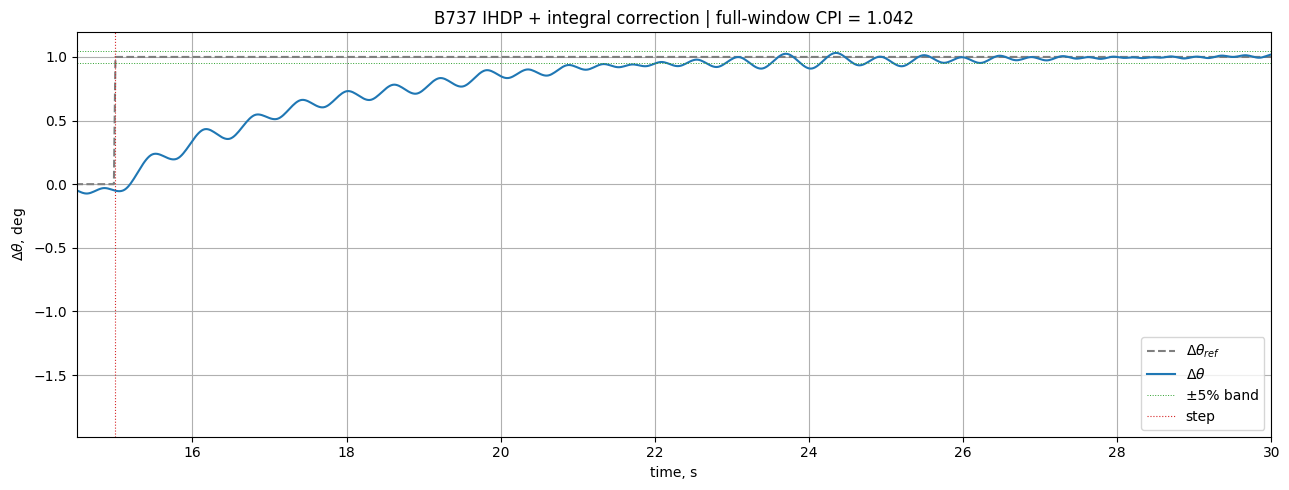

In [9]:
band_deg = 0.05 * step_amplitude_deg
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t_axis, ref_dev_deg_eval, "--", color="tab:gray", label=r"$\Delta\theta_{ref}$")
ax.plot(t_axis, theta_dev_deg, color="tab:blue", label=r"$\Delta\theta$")
ax.axhline(step_amplitude_deg + band_deg, color="tab:green", linestyle=":", linewidth=0.7, label="±5% band")
ax.axhline(step_amplitude_deg - band_deg, color="tab:green", linestyle=":", linewidth=0.7)
ax.axvline(step_time_sec, color="tab:red", linestyle=":", linewidth=0.8, label="step")

if full_post_metrics["command_settling_time"] is not None:
    t_settle = step_time_sec + full_post_metrics["command_settling_time"]
    ax.axvline(t_settle, color="tab:orange", linestyle="-.", linewidth=0.9,
               label=f"command settling = {full_post_metrics['command_settling_time']:.2f} s")

ax.set_xlim(step_time_sec - 0.5, min(t_axis[-1], step_time_sec + bench_window_sec))
ax.set_xlabel("time, s")
ax.set_ylabel(r"$\Delta\theta$, deg")
ax.set_title(f"B737 IHDP + integral correction | full-window CPI = {full_post_metrics['performance_index']:.3f}")
ax.grid(True)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## 10. Notes

* The rollout is executed through `gym.make("NonlinearB737-v0", ...)`; the notebook does not instantiate `NonlinearB737Env` directly.
* The controller combines IHDP with integral correction around a fixed cruise trim. The integral correction is outside the basic paper algorithm.
* The fixed trim terms are required by the nonlinear aircraft model: without trim elevator and trim throttle, the aircraft is not at the selected operating point before learning starts.
* The agent is tuned for this operating point and this $1^\circ$ step. A different speed, altitude or command amplitude should be re-trimmed and re-tuned.
* The `ControlBenchmark` CPI is lower-is-better. The primary CPI uses the complete post-step interval. The 15-second score uses a different window and is shown separately.
